In [176]:
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")


Loaded session_05Apr26_0459H.bin Total samples per channel: 5,083,975
Visible channels for plotting: CH2
 Early window: start_sample=3,000,000, end_sample=3,010,000, sample_count=10,000
Middle window: start_sample=2,536,987, end_sample=2,546,987, sample_count=10,000
  Late window: start_sample=4,073,975, end_sample=4,083,975, sample_count=10,000



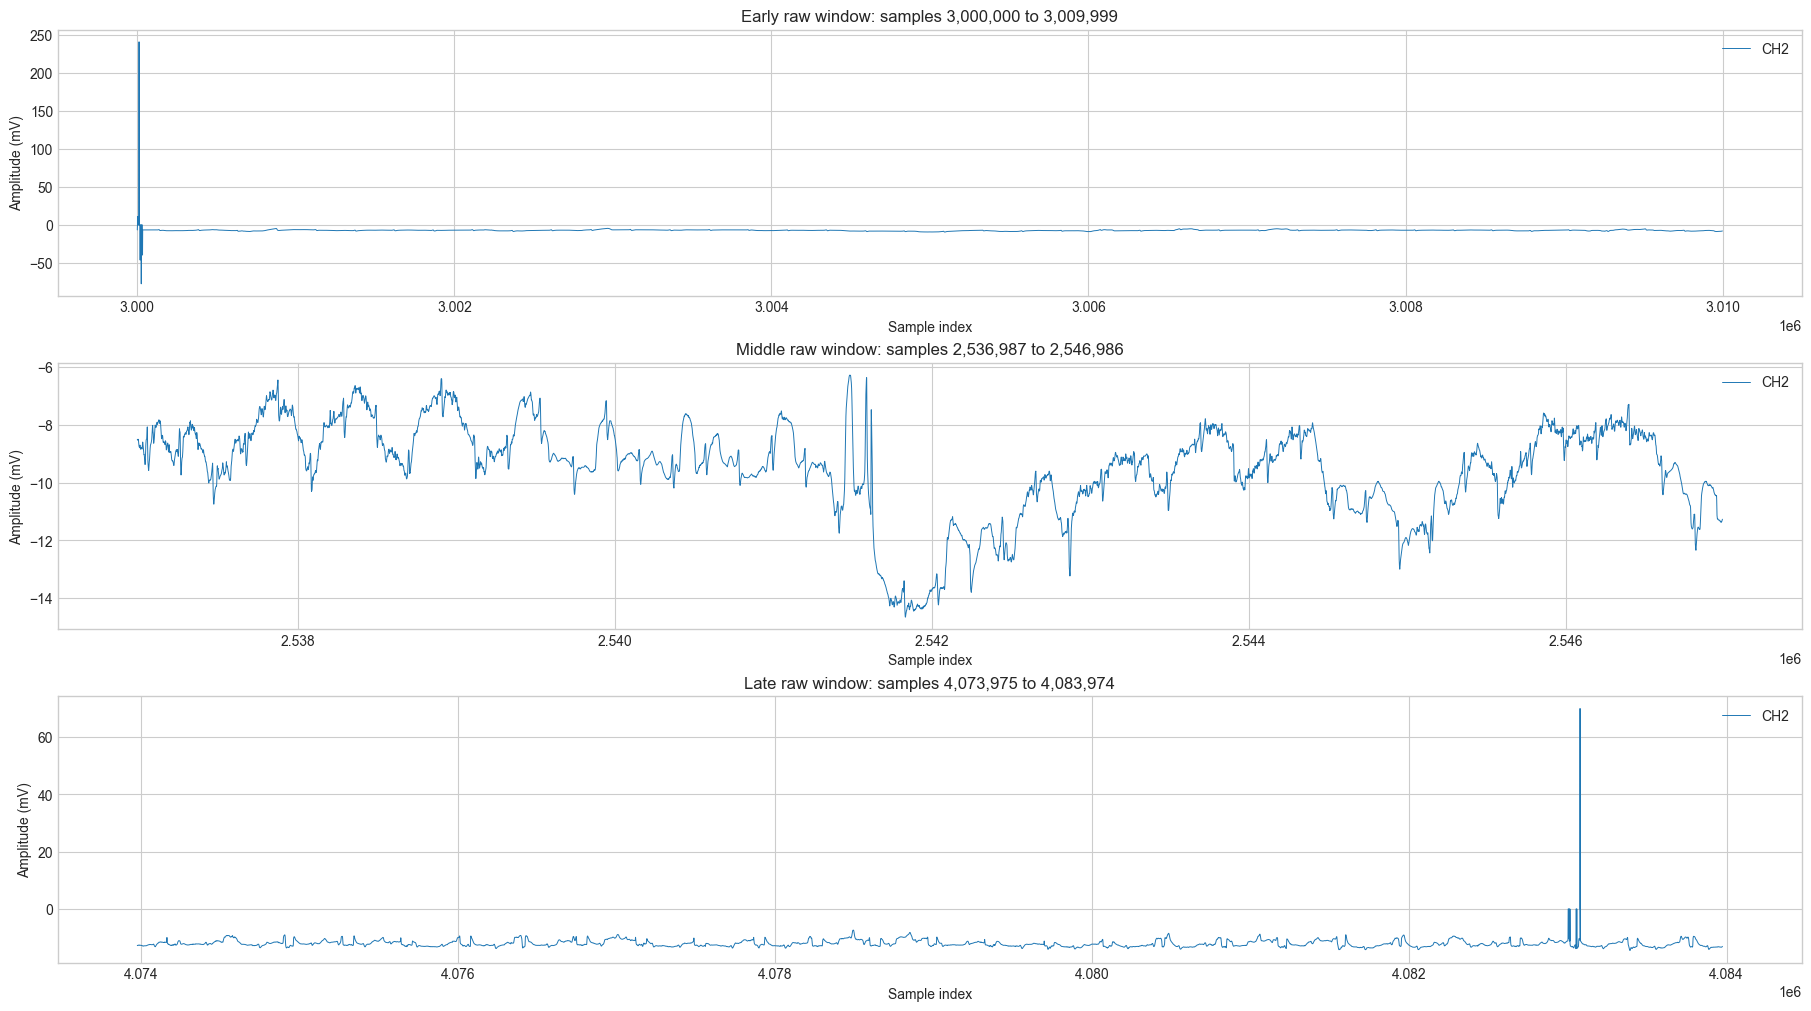

In [177]:
RAW_FILE = Path("session_05Apr26_0459H.bin")
PACKET_BYTES = 231
STATUS_BYTES = 3
SAMPLES_PER_PACKET = 25
CHANNEL_LABELS = ["CH2", "CH3", "CH4"]
BYTES_PER_SAMPLE = 3
WINDOW_SAMPLES = 10_000  # 20 seconds at 500 Hz
ADS1298_VREF = 2.4
ADS1298_GAIN = 6
ADS1298_MAX_CODE = (2**23) - 1
SHOW_CH2 = False
SHOW_CH3 = False
SHOW_CH4 = False

# Toggle these flags to show or hide individual channels in the plots only.
SHOW_CH2 = True
# SHOW_CH3 = True
# SHOW_CH4 = True


def read24_signed_be(buffer: bytes, offset: int) -> int:
    value = (buffer[offset] << 16) | (buffer[offset + 1] << 8) | buffer[offset + 2]
    if value & 0x800000:
        value -= 0x1000000
    return value


def counts_to_mv(count: int) -> float:
    return (count / ADS1298_MAX_CODE) * (ADS1298_VREF / ADS1298_GAIN) * 1000.0


def decode_ads1298_packets(payload: bytes) -> Dict[str, np.ndarray]:
    packet_count = len(payload) // PACKET_BYTES
    channels: Dict[str, List[float]] = {label: [] for label in CHANNEL_LABELS}

    for packet_index in range(packet_count):
        base = packet_index * PACKET_BYTES
        offset = base + STATUS_BYTES
        for label in CHANNEL_LABELS:
            for _ in range(SAMPLES_PER_PACKET):
                channels[label].append(counts_to_mv(read24_signed_be(payload, offset)))
                offset += BYTES_PER_SAMPLE

    return {label: np.asarray(values, dtype=np.float64) for label, values in channels.items()}


payload = RAW_FILE.read_bytes()
channels = decode_ads1298_packets(payload)
total_samples = len(channels["CH2"])

window_starts = {
    "Early": 3000000,
    "Middle": max(0, (total_samples // 2) - (WINDOW_SAMPLES // 2)),
    "Late": max(0, total_samples - 1000000 - WINDOW_SAMPLES),
}

channel_visibility = {
    "CH2": SHOW_CH2,
    "CH3": SHOW_CH3,
    "CH4": SHOW_CH4,
}
active_channels = [label for label in CHANNEL_LABELS if channel_visibility[label]]
if not active_channels:
    raise ValueError("Enable at least one of SHOW_CH2 / SHOW_CH3 / SHOW_CH4.")

print(f"Loaded {RAW_FILE.name} Total samples per channel: {total_samples:,}")
print(f"Visible channels for plotting: {', '.join(active_channels)}")
for window_label, start in window_starts.items():
    end = min(total_samples, start + WINDOW_SAMPLES)
    print(f"{window_label:>6} window: start_sample={start:,}, end_sample={end:,}, sample_count={end - start:,}")
print()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 10), sharex=False, constrained_layout=True)
colors = {"CH2": "#1f77b4", "CH3": "#ff7f0e", "CH4": "#2ca02c"}

for axis, (window_label, start) in zip(axes, window_starts.items()):
    end = min(total_samples, start + WINDOW_SAMPLES)
    sample_axis = np.arange(start, end)
    for channel_label in active_channels:
        axis.plot(sample_axis, channels[channel_label][start:end], linewidth=0.7, label=channel_label, color=colors[channel_label])
    axis.set_title(f"{window_label} raw window: samples {start:,} to {end - 1:,}")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Amplitude (mV)")
    axis.legend(loc="upper right")

plt.show()


In [178]:
FULL_SIGNAL_STATS_ABS_MV_LIMIT = 100.0

print(f"Full-signal statistics across the entire decoded recording (ignoring |sample| > {FULL_SIGNAL_STATS_ABS_MV_LIMIT:.0f} mV):")
for channel_label in CHANNEL_LABELS:
    channel_values = channels[channel_label]
    valid_values = channel_values[np.abs(channel_values) <= FULL_SIGNAL_STATS_ABS_MV_LIMIT]
    excluded_count = len(channel_values) - len(valid_values)
    if len(valid_values) == 0:
        print(f"  {channel_label}: no samples remain after filtering |sample| > {FULL_SIGNAL_STATS_ABS_MV_LIMIT:.0f} mV")
        continue
    print(
        f"  {channel_label}: mean={valid_values.mean():8.3f} mV | min={valid_values.min():8.3f} mV | max={valid_values.max():8.3f} mV | std={valid_values.std():8.3f} mV | kept={len(valid_values):,} | excluded={excluded_count:,}"
    )


Full-signal statistics across the entire decoded recording (ignoring |sample| > 100 mV):
  CH2: mean=  -8.810 mV | min= -91.843 mV | max=  98.438 mV | std=   4.601 mV | kept=5,083,835 | excluded=140
  CH3: mean=   6.993 mV | min= -99.982 mV | max=  96.875 mV | std=  28.550 mV | kept=5,080,598 | excluded=3,377
  CH4: mean= -42.605 mV | min=-100.000 mV | max=  90.625 mV | std=  13.527 mV | kept=4,679,167 | excluded=404,808


Early window for cleaning comparison: start_sample=3,000,000, end_sample=3,010,000, sample_count=10,000
R-peak channel used for downstream analysis: CH2
      neurokit: detected_peaks=  38
       biosppy: detected_peaks=  40
  hamilton2002: detected_peaks=  40
      combined: candidate_peaks=  41 (merge tolerance = ±60 samples)


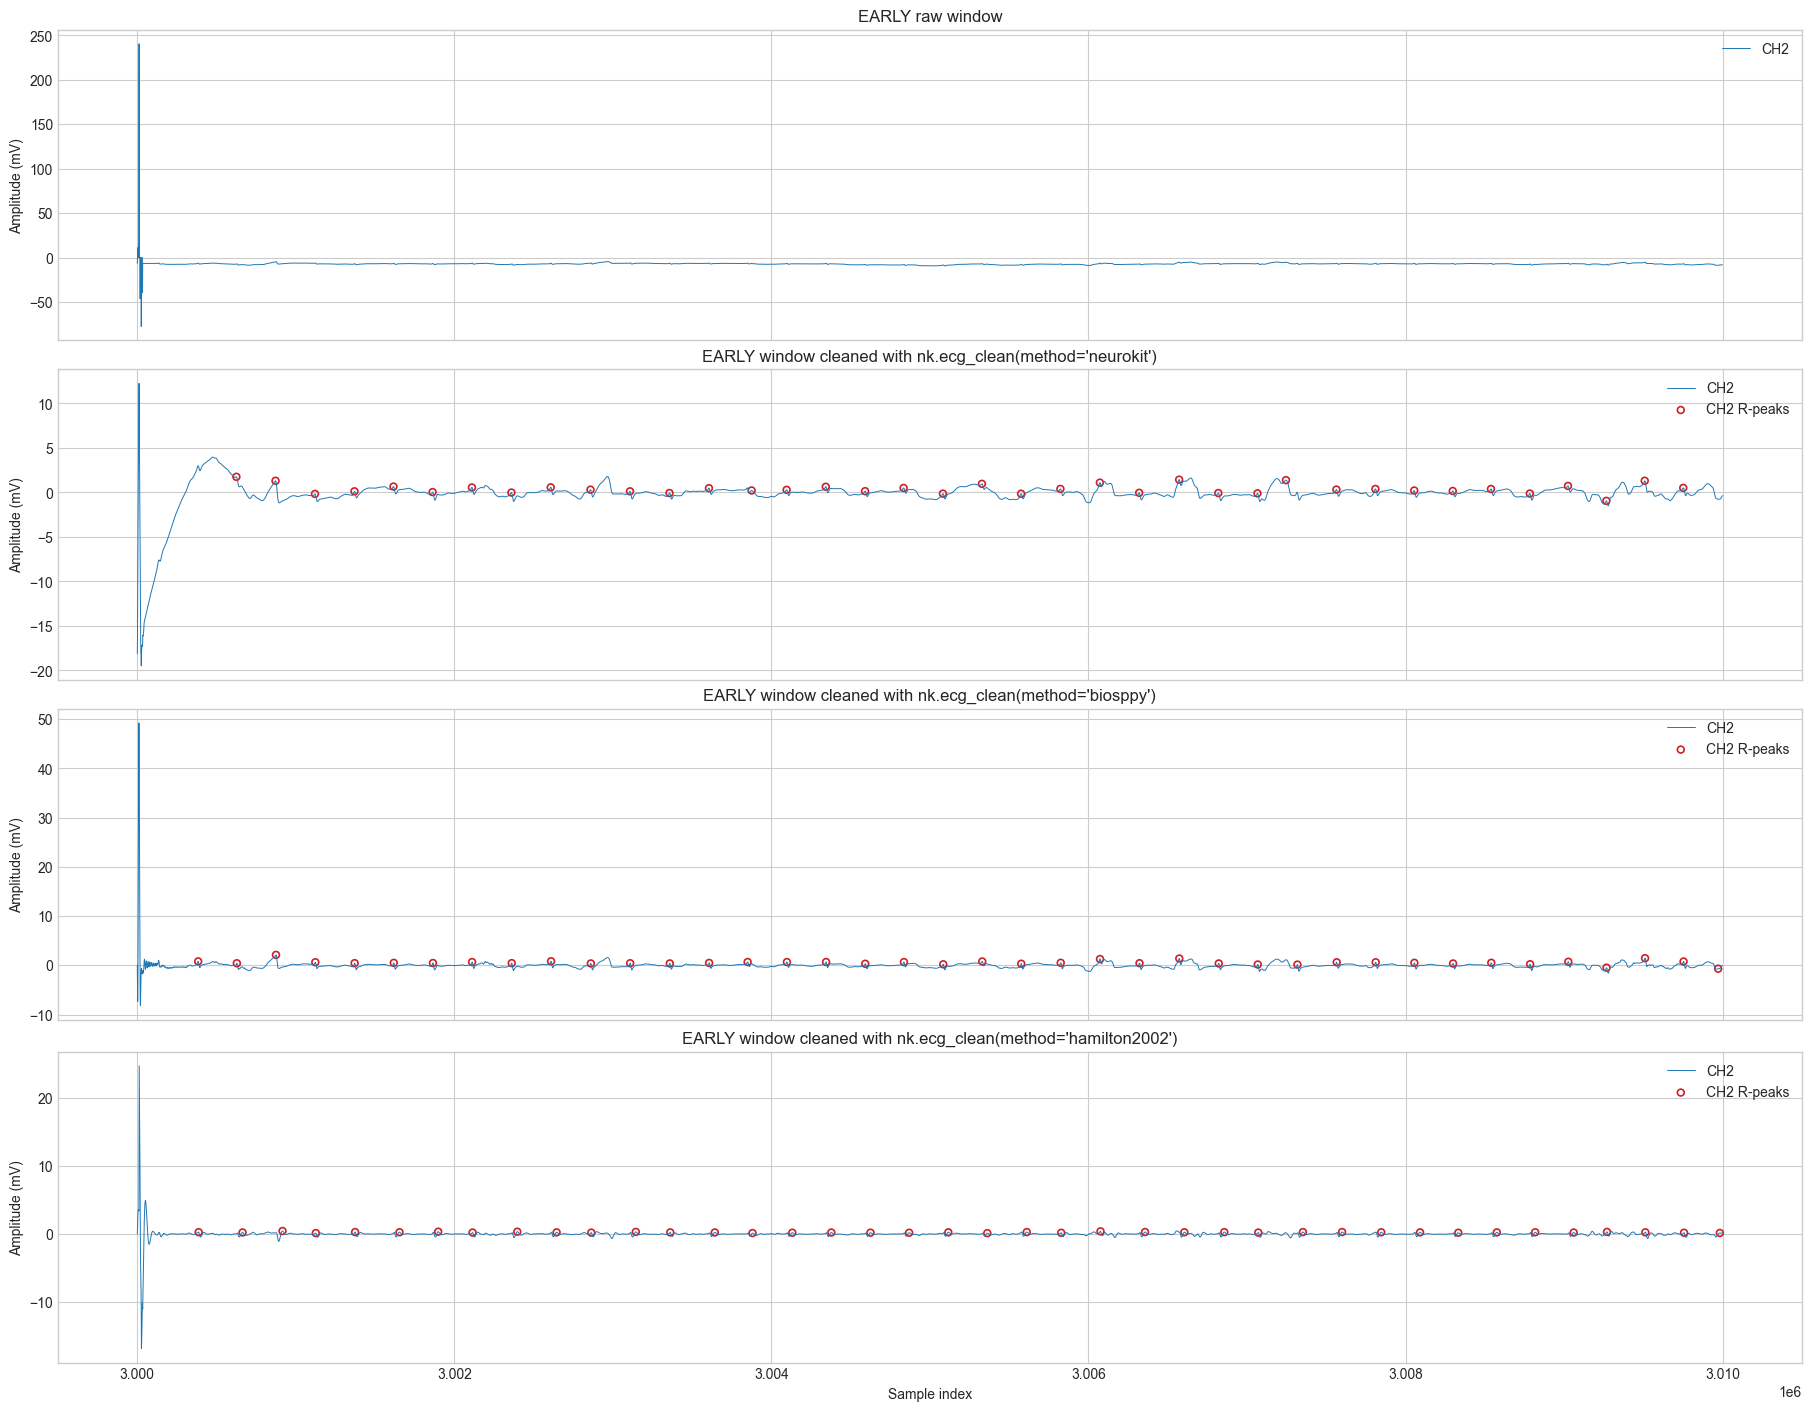

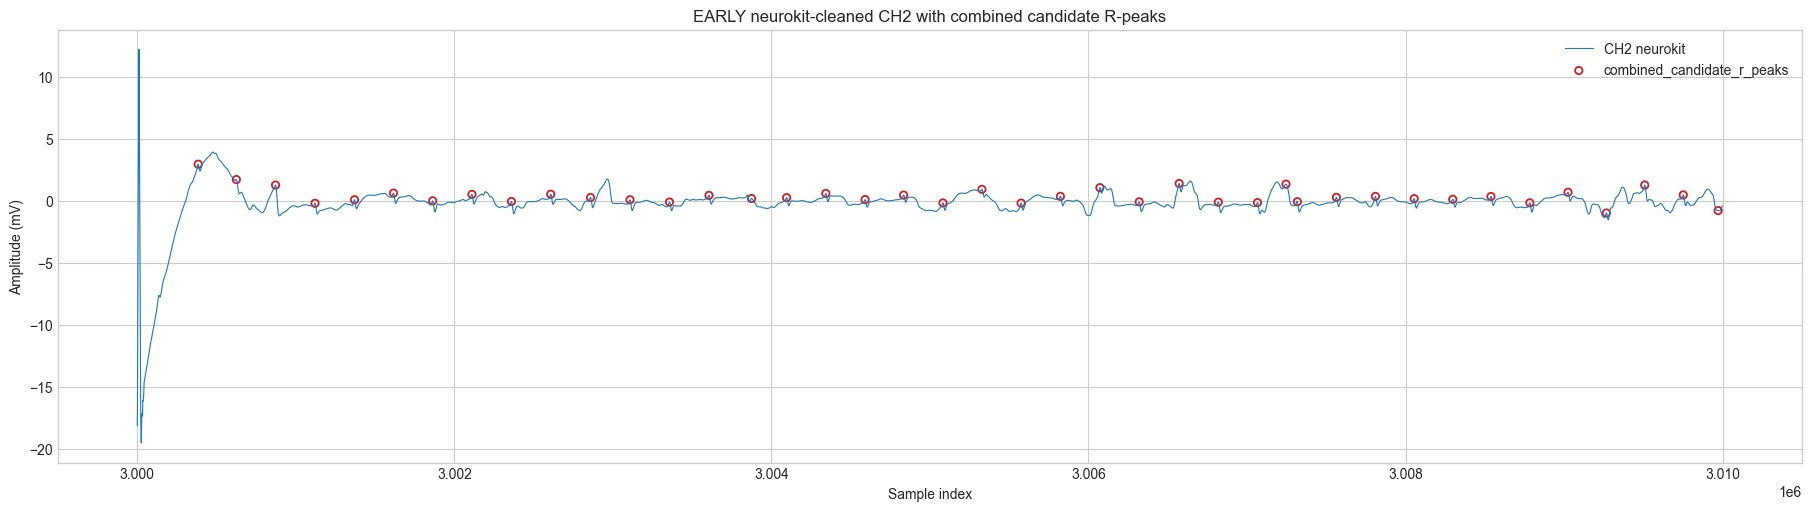

In [179]:
# Subsequent cleaning steps use the sample window defined in the EARLY raw window only.

early_start = window_starts["Early"]
early_end = min(total_samples, early_start + WINDOW_SAMPLES)
early_sample_axis = np.arange(early_start, early_end)

R_PEAK_CHANNEL = "CH2"
R_PEAK_MERGE_TOLERANCE_SAMPLES = 60

cleaning_methods = {
    "neurokit": "neurokit",
    "biosppy": "biosppy",
    "hamilton2002": "hamilton2002",
}

cleaned_windows = {
    method_label: {
        channel_label: nk.ecg_clean(
            channels[channel_label][early_start:early_end],
            sampling_rate=500,
            method=method_name,
        )
        for channel_label in CHANNEL_LABELS
    }
    for method_label, method_name in cleaning_methods.items()
}

plot_series = {
    "raw": {channel_label: channels[channel_label][early_start:early_end] for channel_label in CHANNEL_LABELS},
    **cleaned_windows,
}

peak_indices_by_method = {}
for method_label in cleaning_methods.keys():
    _, peak_info = nk.ecg_peaks(
        cleaned_windows[method_label][R_PEAK_CHANNEL],
        sampling_rate=500,
        method="neurokit",
        correct_artifacts=False,
    )
    peak_indices_by_method[method_label] = np.asarray(peak_info.get("ECG_R_Peaks", np.array([], dtype=int)), dtype=int)


def choose_cluster_representative(cluster: list[int], candidate_groups: dict[str, np.ndarray], reference_signal: np.ndarray) -> int:
    neurokit_candidates = set(int(peak) for peak in np.asarray(candidate_groups["neurokit"], dtype=int))
    neurokit_cluster_peaks = [peak for peak in cluster if peak in neurokit_candidates]
    if neurokit_cluster_peaks:
        return int(max(neurokit_cluster_peaks, key=lambda idx: reference_signal[idx] if 0 <= idx < len(reference_signal) else float("-inf")))
    return int(max(cluster, key=lambda idx: reference_signal[idx] if 0 <= idx < len(reference_signal) else float("-inf")))


def merge_r_peak_candidates(candidate_groups: dict[str, np.ndarray], reference_signal: np.ndarray, tolerance: int) -> np.ndarray:
    all_candidates = sorted(int(peak) for peaks in candidate_groups.values() for peak in np.asarray(peaks, dtype=int))
    if not all_candidates:
        return np.array([], dtype=int)

    merged = []
    cluster = [all_candidates[0]]

    for peak in all_candidates[1:]:
        if peak - cluster[-1] <= tolerance:
            cluster.append(peak)
        else:
            merged.append(choose_cluster_representative(cluster, candidate_groups, reference_signal))
            cluster = [peak]

    merged.append(choose_cluster_representative(cluster, candidate_groups, reference_signal))
    return np.asarray(sorted(set(merged)), dtype=int)


combined_candidate_r_peaks = merge_r_peak_candidates(
    peak_indices_by_method,
    cleaned_windows["neurokit"][R_PEAK_CHANNEL],
    R_PEAK_MERGE_TOLERANCE_SAMPLES,
)

print(f"Early window for cleaning comparison: start_sample={early_start:,}, end_sample={early_end:,}, sample_count={early_end - early_start:,}")
print(f"R-peak channel used for downstream analysis: {R_PEAK_CHANNEL}")
for method_label, peaks in peak_indices_by_method.items():
    print(f"  {method_label:>12}: detected_peaks={len(peaks):4d}")
print(f"  {'combined':>12}: candidate_peaks={len(combined_candidate_r_peaks):4d} (merge tolerance = ±{R_PEAK_MERGE_TOLERANCE_SAMPLES} samples)")

fig, axes = plt.subplots(
    nrows=1 + len(cleaning_methods),
    ncols=1,
    figsize=(18, 14),
    sharex=True,
    constrained_layout=True,
)

colors = {"CH2": "#1f77b4", "CH3": "#ff7f0e", "CH4": "#2ca02c", "circle": "#ce1f26"}


def plot_with_r_peaks(axis, series_label: str, title: str, peak_indices: np.ndarray | None = None) -> None:
    series_by_channel = plot_series[series_label]
    for channel_label in active_channels:
        series = series_by_channel[channel_label]
        axis.plot(
            early_sample_axis,
            series,
            linewidth=0.7,
            label=channel_label,
            color=colors[channel_label],
        )

    if peak_indices is not None and R_PEAK_CHANNEL in active_channels:
        reference_series = series_by_channel[R_PEAK_CHANNEL]
        valid_peak_indices = np.asarray(peak_indices, dtype=int)
        valid_peak_indices = valid_peak_indices[(valid_peak_indices >= 0) & (valid_peak_indices < len(reference_series))]
        if valid_peak_indices.size:
            axis.scatter(
                early_sample_axis[valid_peak_indices],
                reference_series[valid_peak_indices],
                s=24,
                facecolors="none",
                edgecolors=colors["circle"],
                linewidths=1.2,
                label=f"{R_PEAK_CHANNEL} R-peaks",
            )

    axis.set_title(title)
    axis.set_ylabel("Amplitude (mV)")
    axis.legend(loc="upper right", ncol=min(2, max(1, len(active_channels))))

plot_with_r_peaks(axes[0], "raw", "EARLY raw window")
for axis, method_label in zip(axes[1:], cleaning_methods.keys()):
    plot_with_r_peaks(
        axis,
        method_label,
        f"EARLY window cleaned with nk.ecg_clean(method='{method_label}')",
        peak_indices=peak_indices_by_method[method_label],
    )

axes[-1].set_xlabel("Sample index")
plt.show()

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
neurokit_ch2 = cleaned_windows["neurokit"][R_PEAK_CHANNEL]
ax.plot(
    early_sample_axis,
    neurokit_ch2,
    linewidth=0.8,
    color="#1f77b4",
    label=f"{R_PEAK_CHANNEL} neurokit",
)
if len(combined_candidate_r_peaks):
    ax.scatter(
        early_start + combined_candidate_r_peaks,
        neurokit_ch2[combined_candidate_r_peaks],
        s=28,
        facecolors="none",
        edgecolors="#ce1f26",
        linewidths=1.3,
        label="combined_candidate_r_peaks",
    )
ax.set_title("EARLY neurokit-cleaned CH2 with combined candidate R-peaks")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
plt.show()


EARLY window | combined candidates on neurokit-cleaned CH2: candidates=  41 | filtered_r_peaks=  32 | false_r_peaks=   9


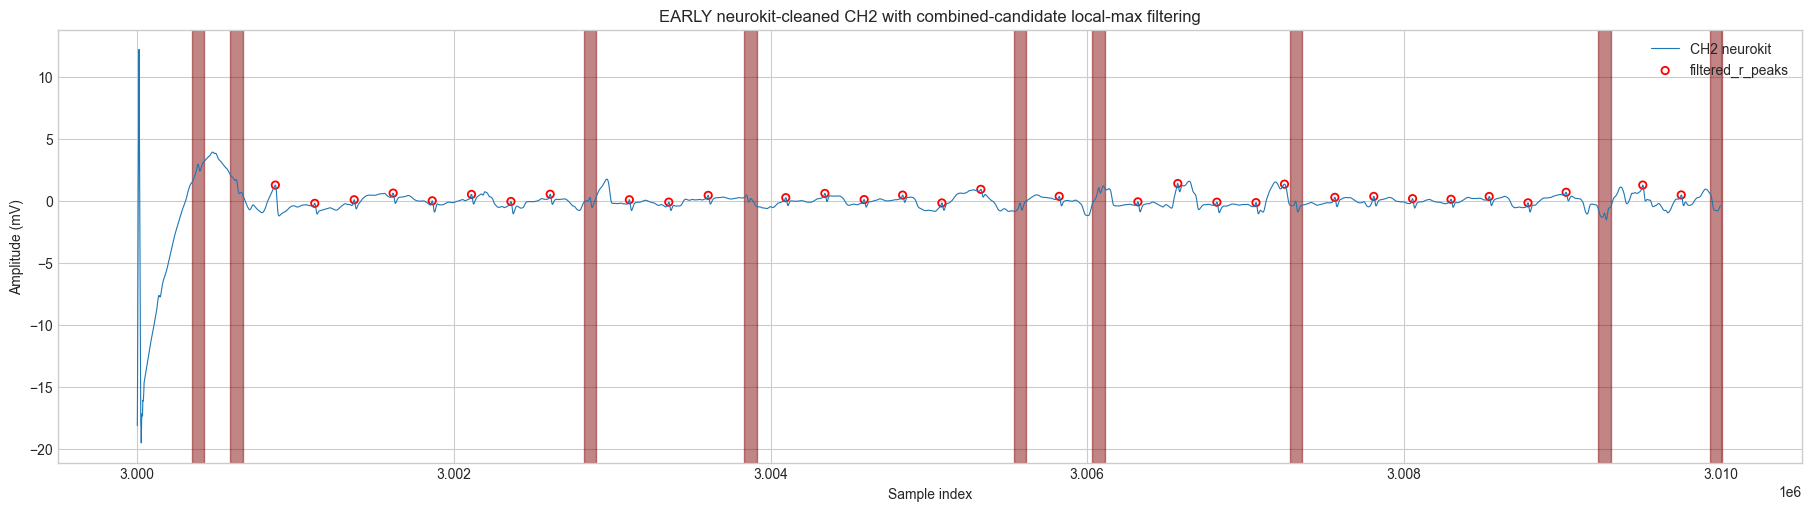

In [180]:
LOCAL_MAX_RADIUS_SAMPLES = 40
FILTER_CHANNEL = R_PEAK_CHANNEL


def filter_r_peaks_local_maxima(signal: np.ndarray, candidate_r_peaks: np.ndarray, radius: int = LOCAL_MAX_RADIUS_SAMPLES):
    filtered_r_peaks = []
    false_r_peaks = []

    for peak in np.asarray(candidate_r_peaks, dtype=int):
        if peak < 0 or peak >= len(signal):
            false_r_peaks.append(int(peak))
            continue

        left = max(0, peak - radius)
        right = min(len(signal), peak + radius + 1)
        local_window = signal[left:right]
        local_max_index = left + int(np.argmax(local_window))

        if peak == local_max_index:
            filtered_r_peaks.append(int(peak))
        else:
            false_r_peaks.append(int(peak))

    return np.asarray(filtered_r_peaks, dtype=int), np.asarray(false_r_peaks, dtype=int)


filtered_r_peaks, false_r_peaks = filter_r_peaks_local_maxima(
    cleaned_windows["neurokit"][FILTER_CHANNEL],
    combined_candidate_r_peaks,
)

print(
    f"EARLY window | combined candidates on neurokit-cleaned {FILTER_CHANNEL}: candidates={len(combined_candidate_r_peaks):4d} | filtered_r_peaks={len(filtered_r_peaks):4d} | false_r_peaks={len(false_r_peaks):4d}"
)

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
series = cleaned_windows["neurokit"][FILTER_CHANNEL]
ax.plot(
    early_sample_axis,
    series,
    linewidth=0.8,
    color="#1f77b4",
    label=f"{FILTER_CHANNEL} neurokit",
)

for peak in false_r_peaks:
    peak_sample = early_start + int(peak)
    ax.axvspan(
        peak_sample - LOCAL_MAX_RADIUS_SAMPLES,
        peak_sample + LOCAL_MAX_RADIUS_SAMPLES,
        color="maroon",
        alpha=0.48,
    )

if len(filtered_r_peaks):
    ax.scatter(
        early_start + filtered_r_peaks,
        series[filtered_r_peaks],
        s=28,
        facecolors="none",
        edgecolors="red",
        linewidths=1.3,
        label="filtered_r_peaks",
    )

ax.set_title("EARLY neurokit-cleaned CH2 with combined-candidate local-max filtering")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
plt.show()


Extraction series: neurokit
Extraction channel: CH2
Candidate filtered R-peaks: 32
Extracted heartbeat segments: 32
First 5 extracted beats:
  beat_index=  1 | r_peak_sample=3,000,872 | start_sample=3,000,738 | end_sample=3,000,996 | segment_len= 259
  beat_index=  2 | r_peak_sample=3,001,121 | start_sample=3,000,997 | end_sample=3,001,245 | segment_len= 249
  beat_index=  3 | r_peak_sample=3,001,370 | start_sample=3,001,246 | end_sample=3,001,493 | segment_len= 248
  beat_index=  4 | r_peak_sample=3,001,616 | start_sample=3,001,493 | end_sample=3,001,740 | segment_len= 248
  beat_index=  5 | r_peak_sample=3,001,863 | start_sample=3,001,739 | end_sample=3,001,987 | segment_len= 249


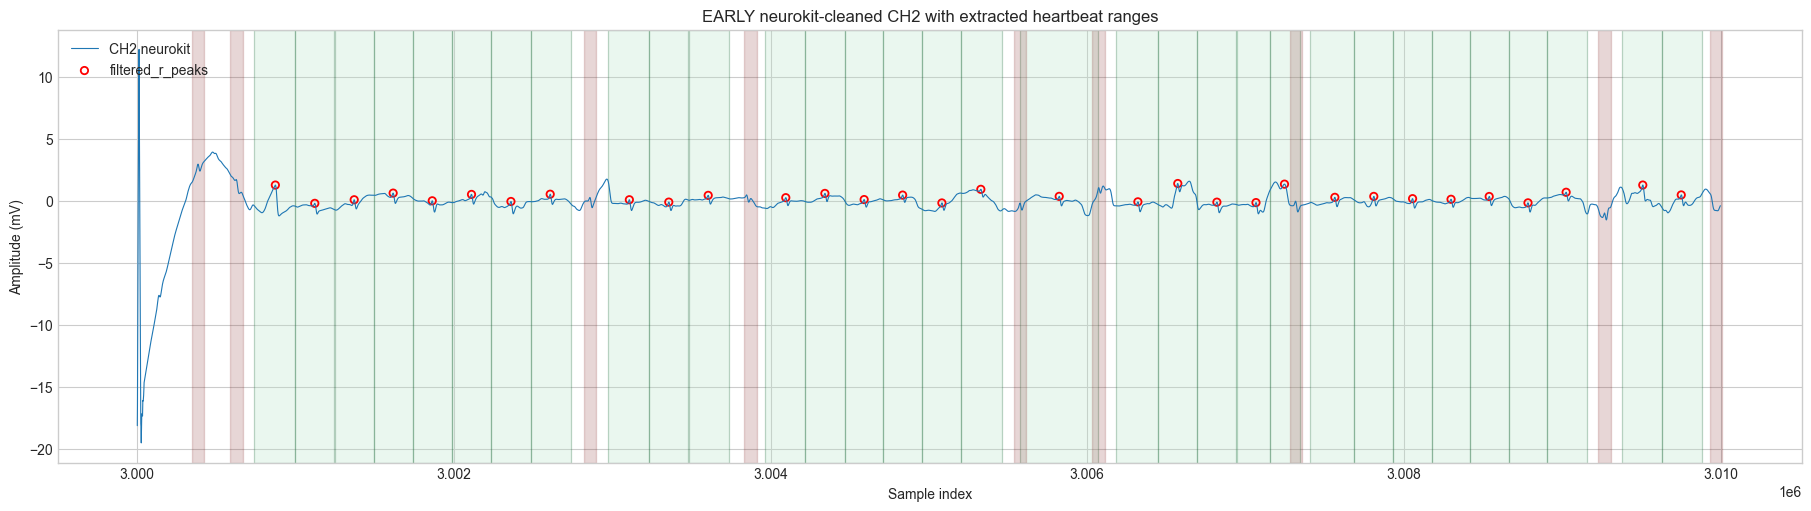

In [181]:
# Cell 6: Extract heartbeat segments from the EARLY CH2 signal cleaned with the neurokit method.
# Each non-edge beat uses 50% of the RR distance to the previous R-peak as the left boundary,
# and 50% of the RR distance to the next R-peak as the right boundary.
# Edge beats use 50% of the only available RR distance, then add a fixed bias.

EXTRACTION_SERIES = "neurokit"
EXTRACTION_CHANNEL = "CH2"
EDGE_BIAS_SAMPLES = 10
RR_ASYMMETRY_RATIO = 1.5
RR_ASYMMETRY_BIAS_SAMPLES = 20
MIN_BEAT_SIDE_SAMPLES = 80
MAX_BEAT_SIDE_SAMPLES = 300

source_signal = cleaned_windows[EXTRACTION_SERIES][EXTRACTION_CHANNEL]
source_r_peaks = np.asarray(filtered_r_peaks, dtype=int)
source_false_r_peaks = np.asarray(false_r_peaks, dtype=int)

heartbeat_segments = []

for beat_index in range(len(source_r_peaks)):
    current_peak = int(source_r_peaks[beat_index])

    if beat_index == 0:
        if len(source_r_peaks) < 2:
            continue
        next_peak = int(source_r_peaks[beat_index + 1])
        right_rr = next_peak - current_peak
        left_reach = int(round((0.5 * right_rr) + EDGE_BIAS_SAMPLES))
        right_reach = int(round(0.5 * right_rr))
    elif beat_index == len(source_r_peaks) - 1:
        prev_peak = int(source_r_peaks[beat_index - 1])
        left_rr = current_peak - prev_peak
        left_reach = int(round(0.5 * left_rr))
        right_reach = int(round((0.5 * left_rr) + EDGE_BIAS_SAMPLES))
    else:
        prev_peak = int(source_r_peaks[beat_index - 1])
        next_peak = int(source_r_peaks[beat_index + 1])

        left_rr = current_peak - prev_peak
        right_rr = next_peak - current_peak

        smaller_rr = min(left_rr, right_rr)
        larger_rr = max(left_rr, right_rr)
        if larger_rr >= RR_ASYMMETRY_RATIO * smaller_rr:
            adjusted_rr = smaller_rr + RR_ASYMMETRY_BIAS_SAMPLES
            if left_rr > right_rr:
                left_rr = adjusted_rr
            else:
                right_rr = adjusted_rr

        left_reach = int(round(0.5 * left_rr))
        right_reach = int(round(0.5 * right_rr))

    left_reach = max(MIN_BEAT_SIDE_SAMPLES, min(MAX_BEAT_SIDE_SAMPLES, left_reach))
    right_reach = max(MIN_BEAT_SIDE_SAMPLES, min(MAX_BEAT_SIDE_SAMPLES, right_reach))

    left_boundary = current_peak - left_reach
    right_boundary = current_peak + right_reach

    if left_boundary < 0 or right_boundary >= len(source_signal):
        continue
    if right_boundary <= left_boundary:
        continue

    local_r_peak = current_peak - left_boundary
    heartbeat_segments.append(
        {
            "beat_index": len(heartbeat_segments) + 1,
            "r_peak_sample": current_peak,
            "start_sample": early_start + left_boundary,
            "end_sample": early_start + right_boundary,
            "local_r_peak": local_r_peak,
            "signal": source_signal[left_boundary : right_boundary + 1].copy(),
        }
    )

print(f"Extraction series: {EXTRACTION_SERIES}")
print(f"Extraction channel: {EXTRACTION_CHANNEL}")
print(f"Candidate filtered R-peaks: {len(source_r_peaks):,}")
print(f"Extracted heartbeat segments: {len(heartbeat_segments):,}")
if heartbeat_segments:
    print("First 5 extracted beats:")
    for beat in heartbeat_segments[:5]:
        print(
            f"  beat_index={beat['beat_index']:>3} | "
            f"r_peak_sample={early_start + beat['r_peak_sample']:,} | "
            f"start_sample={beat['start_sample']:,} | "
            f"end_sample={beat['end_sample']:,} | "
            f"segment_len={len(beat['signal']):>4}"
        )

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
plot_x = early_start + np.arange(len(source_signal))
ax.plot(plot_x, source_signal, linewidth=0.8, color="#1f77b4", label=f"{EXTRACTION_CHANNEL} {EXTRACTION_SERIES}")

for beat in heartbeat_segments:
    ax.axvspan(
        beat["start_sample"],
        beat["end_sample"],
        facecolor="#b7e4c7",
        edgecolor="#166534",
        linewidth=0.9,
        alpha=0.28,
    )

if len(source_r_peaks):
    ax.scatter(
        early_start + source_r_peaks,
        source_signal[source_r_peaks],
        s=28,
        facecolors="none",
        edgecolors="red",
        linewidths=1.3,
        label="filtered_r_peaks",
    )

for peak in source_false_r_peaks:
    peak_sample = early_start + int(peak)
    ax.axvspan(
        peak_sample - LOCAL_MAX_RADIUS_SAMPLES,
        peak_sample + LOCAL_MAX_RADIUS_SAMPLES,
        color="#7f1d1d",
        alpha=0.18,
    )

ax.set_title("EARLY neurokit-cleaned CH2 with extracted heartbeat ranges")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper left")
plt.show()


ENFORCE_R_IS_MAX_REJECTION=False
Total extracted beats: 32
Accepted beats after Cell 7: 32
Rejected beats after Cell 7: 0


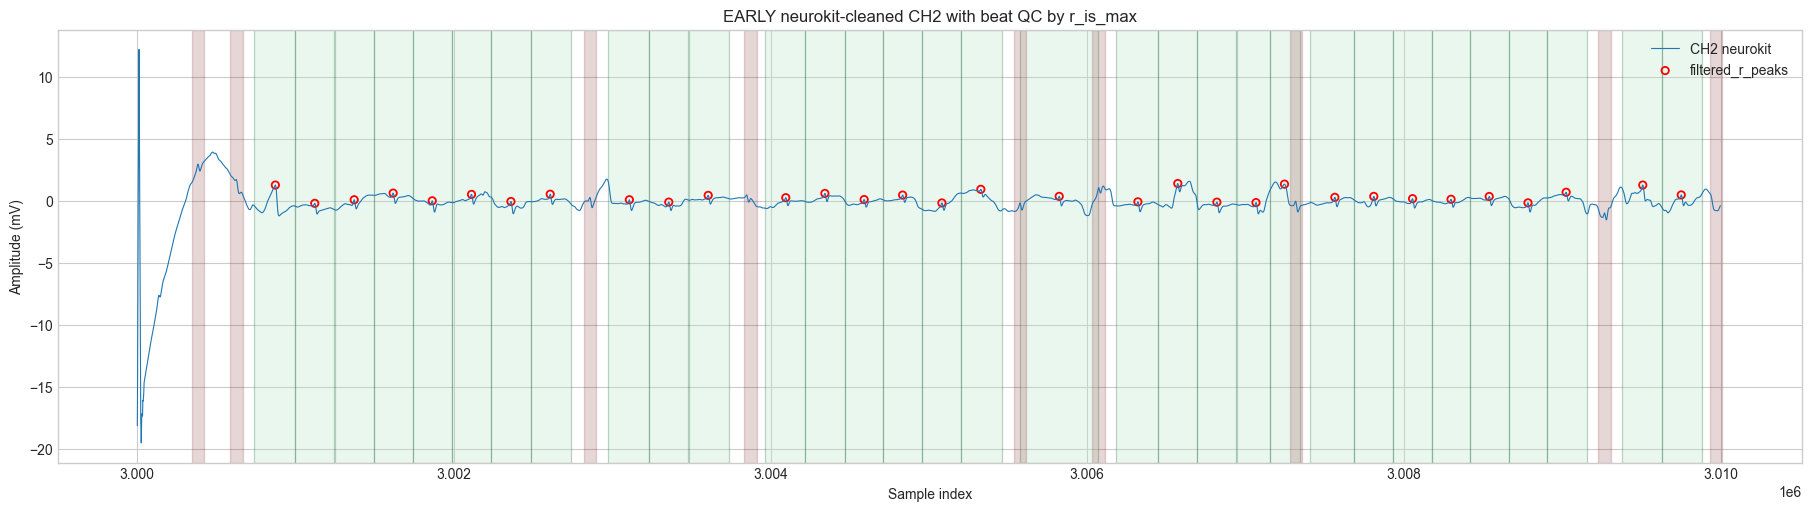

In [182]:
# Cell 7: Beat-level QC using the rule that the intended R-peak should be the maximum within the extracted beat.
# Toggle whether this rule should actually reject beats downstream, or remain advisory only.

ENFORCE_R_IS_MAX_REJECTION = False

heartbeat_qc = []
accepted_heartbeat_segments = []
rejected_heartbeat_segments = []

for beat in heartbeat_segments:
    beat_signal = beat["signal"]
    local_r_peak = int(beat["local_r_peak"])
    r_is_max = bool(local_r_peak == int(np.argmax(beat_signal)))
    failure_reasons = [] if r_is_max else ["r_is_not_max"]

    accepted = r_is_max or (not ENFORCE_R_IS_MAX_REJECTION)
    beat_result = {
        **beat,
        "r_is_max": r_is_max,
        "failure_reasons": failure_reasons,
        "accepted": accepted,
    }
    heartbeat_qc.append(beat_result)
    if accepted:
        accepted_heartbeat_segments.append(beat_result)
    else:
        rejected_heartbeat_segments.append(beat_result)

print(f"ENFORCE_R_IS_MAX_REJECTION={ENFORCE_R_IS_MAX_REJECTION}")
print(f"Total extracted beats: {len(heartbeat_segments):,}")
print(f"Accepted beats after Cell 7: {len(accepted_heartbeat_segments):,}")
print(f"Rejected beats after Cell 7: {len(rejected_heartbeat_segments):,}")

if rejected_heartbeat_segments:
    print("First 10 rejected beats:")
    for beat in rejected_heartbeat_segments[:10]:
        print(
            f"  beat_index={beat['beat_index']:>3} | "
            f"r_peak_sample={early_start + beat['r_peak_sample']:,} | "
            f"start_sample={beat['start_sample']:,} | "
            f"end_sample={beat['end_sample']:,} | "
            f"reason={', '.join(beat['failure_reasons'])}"
        )

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
plot_x = early_start + np.arange(len(source_signal))
ax.plot(plot_x, source_signal, linewidth=0.8, color="#1f77b4", label=f"{EXTRACTION_CHANNEL} {EXTRACTION_SERIES}")

for beat in accepted_heartbeat_segments:
    ax.axvspan(
        beat["start_sample"],
        beat["end_sample"],
        facecolor="#b7e4c7",
        edgecolor="#166534",
        linewidth=0.9,
        alpha=0.28,
    )

for beat in rejected_heartbeat_segments:
    ax.axvspan(
        beat["start_sample"],
        beat["end_sample"],
        facecolor="#d1d5db",
        edgecolor="#4b5563",
        linewidth=0.9,
        alpha=0.85,
    )

if len(source_r_peaks):
    ax.scatter(
        early_start + source_r_peaks,
        source_signal[source_r_peaks],
        s=28,
        facecolors="none",
        edgecolors="red",
        linewidths=1.3,
        label="filtered_r_peaks",
    )

for peak in source_false_r_peaks:
    peak_sample = early_start + int(peak)
    ax.axvspan(
        peak_sample - LOCAL_MAX_RADIUS_SAMPLES,
        peak_sample + LOCAL_MAX_RADIUS_SAMPLES,
        color="#7f1d1d",
        alpha=0.18,
    )

ax.set_title("EARLY neurokit-cleaned CH2 with beat QC by r_is_max")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
plt.show()


Stage 2 thresholds: MAX_BEAT_RANGE_MV=5.00, MAX_BEAT_ABS_DIFF_MV=3.00
Cell 7 accepted beats: 32
Stage 2 accepted beats: 32
Stage 2 rejected beats: 0


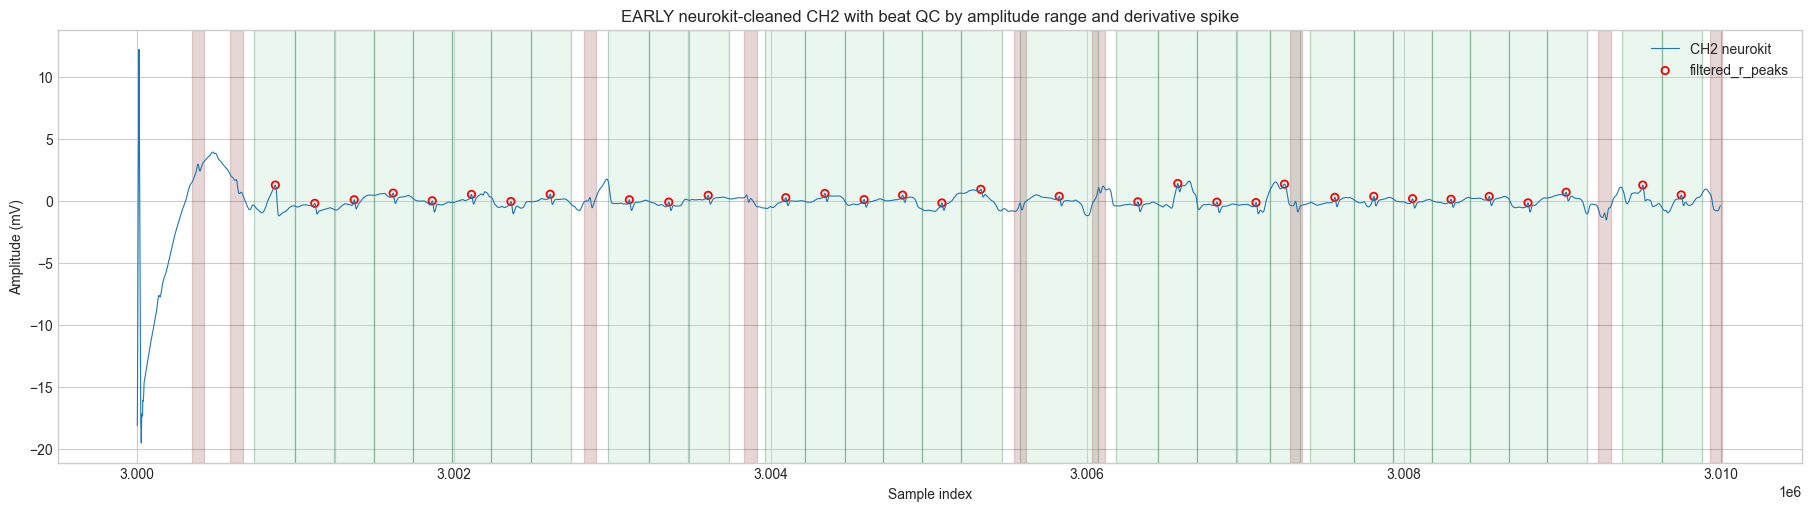

In [183]:
# Cell 8: Additional beat-level QC using conservative thresholds for huge amplitude artifacts and spike-like derivatives.
# This builds on Cell 7 and respects whether Cell 7 treats r_is_not_max as rejecting or advisory.

MAX_BEAT_RANGE_MV = 5.0
MAX_BEAT_ABS_DIFF_MV = 3.0

heartbeat_qc_stage_2 = []
accepted_heartbeat_segments_stage_2 = []
rejected_heartbeat_segments_stage_2 = []

for beat in heartbeat_qc:
    beat_signal = beat["signal"]
    beat_range_mv = float(np.max(beat_signal) - np.min(beat_signal))
    beat_max_abs_diff_mv = float(np.max(np.abs(np.diff(beat_signal)))) if len(beat_signal) > 1 else 0.0

    failure_reasons = [] if beat["accepted"] else list(beat["failure_reasons"])
    if beat_range_mv > MAX_BEAT_RANGE_MV:
        failure_reasons.append("huge_amplitude_artifact")
    if beat_max_abs_diff_mv > MAX_BEAT_ABS_DIFF_MV:
        failure_reasons.append("huge_derivative_spike")

    accepted = len(failure_reasons) == 0
    beat_result = {
        **beat,
        "beat_range_mv": beat_range_mv,
        "beat_max_abs_diff_mv": beat_max_abs_diff_mv,
        "failure_reasons": failure_reasons,
        "accepted": accepted,
    }
    heartbeat_qc_stage_2.append(beat_result)
    if accepted:
        accepted_heartbeat_segments_stage_2.append(beat_result)
    else:
        rejected_heartbeat_segments_stage_2.append(beat_result)

print(f"Stage 2 thresholds: MAX_BEAT_RANGE_MV={MAX_BEAT_RANGE_MV:.2f}, MAX_BEAT_ABS_DIFF_MV={MAX_BEAT_ABS_DIFF_MV:.2f}")
print(f"Cell 7 accepted beats: {len(accepted_heartbeat_segments):,}")
print(f"Stage 2 accepted beats: {len(accepted_heartbeat_segments_stage_2):,}")
print(f"Stage 2 rejected beats: {len(rejected_heartbeat_segments_stage_2):,}")

reason_counts = {}
for beat in rejected_heartbeat_segments_stage_2:
    for reason in beat["failure_reasons"]:
        reason_counts[reason] = reason_counts.get(reason, 0) + 1

if reason_counts:
    print("Stage 2 rejection reasons:")
    for reason, count in sorted(reason_counts.items()):
        print(f"  {reason}: {count}")

if rejected_heartbeat_segments_stage_2:
    print("First 10 stage 2 rejected beats:")
    for beat in rejected_heartbeat_segments_stage_2[:10]:
        print(
            f"  beat_index={beat['beat_index']:>3} | "
            f"r_peak_sample={early_start + beat['r_peak_sample']:,} | "
            f"start_sample={beat['start_sample']:,} | "
            f"end_sample={beat['end_sample']:,} | "
            f"range={beat['beat_range_mv']:.3f} mV | "
            f"max_abs_diff={beat['beat_max_abs_diff_mv']:.3f} mV | "
            f"reason={', '.join(beat['failure_reasons'])}"
        )

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
plot_x = early_start + np.arange(len(source_signal))
ax.plot(plot_x, source_signal, linewidth=0.8, color="#1f77b4", label=f"{EXTRACTION_CHANNEL} {EXTRACTION_SERIES}")

for beat in accepted_heartbeat_segments_stage_2:
    ax.axvspan(
        beat["start_sample"],
        beat["end_sample"],
        facecolor="#b7e4c7",
        edgecolor="#166534",
        linewidth=0.9,
        alpha=0.28,
    )

for beat in rejected_heartbeat_segments_stage_2:
    ax.axvspan(
        beat["start_sample"],
        beat["end_sample"],
        facecolor="#d1d5db",
        edgecolor="#4b5563",
        linewidth=0.9,
        alpha=0.35,
    )

if len(source_r_peaks):
    ax.scatter(
        early_start + source_r_peaks,
        source_signal[source_r_peaks],
        s=28,
        facecolors="none",
        edgecolors="red",
        linewidths=1.3,
        label="filtered_r_peaks",
    )

for peak in source_false_r_peaks:
    peak_sample = early_start + int(peak)
    ax.axvspan(
        peak_sample - LOCAL_MAX_RADIUS_SAMPLES,
        peak_sample + LOCAL_MAX_RADIUS_SAMPLES,
        color="#7f1d1d",
        alpha=0.18,
    )

ax.set_title("EARLY neurokit-cleaned CH2 with beat QC by amplitude range and derivative spike")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
plt.show()


Accepted beats available for delineation plotting: 32
Accepted R-peaks used for continuous delineation: 32


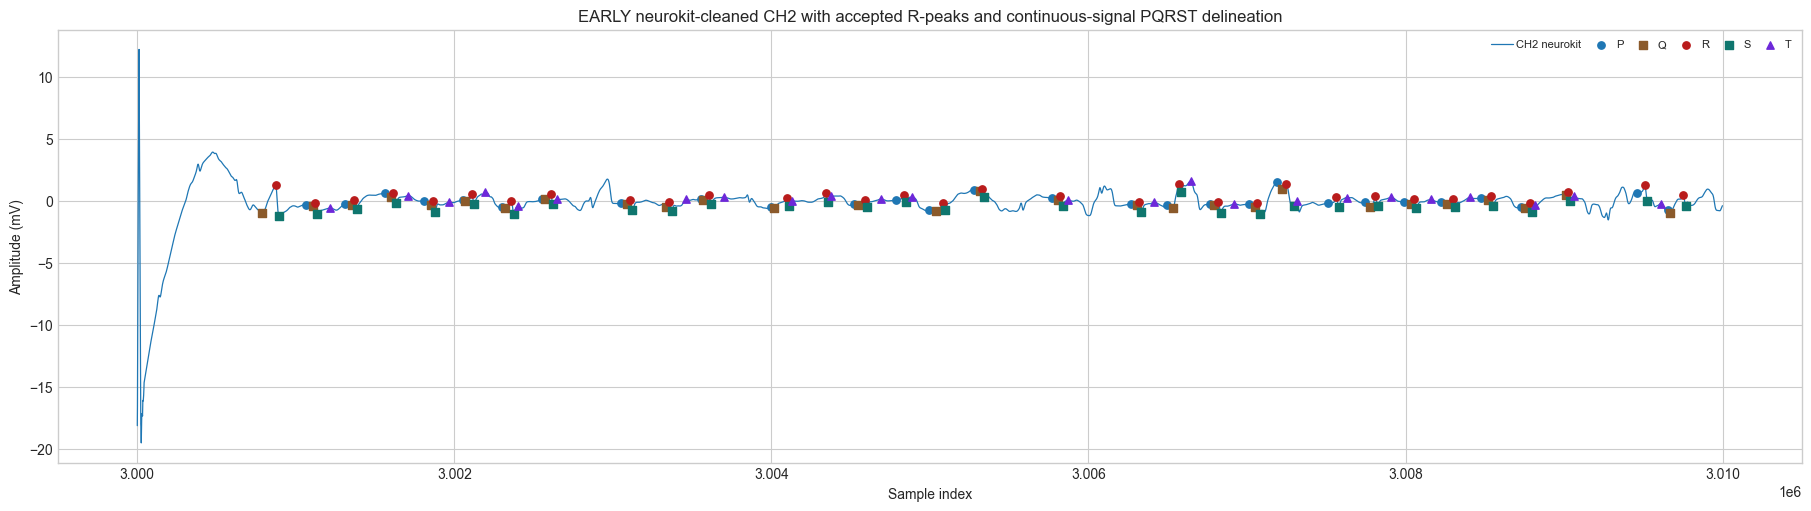

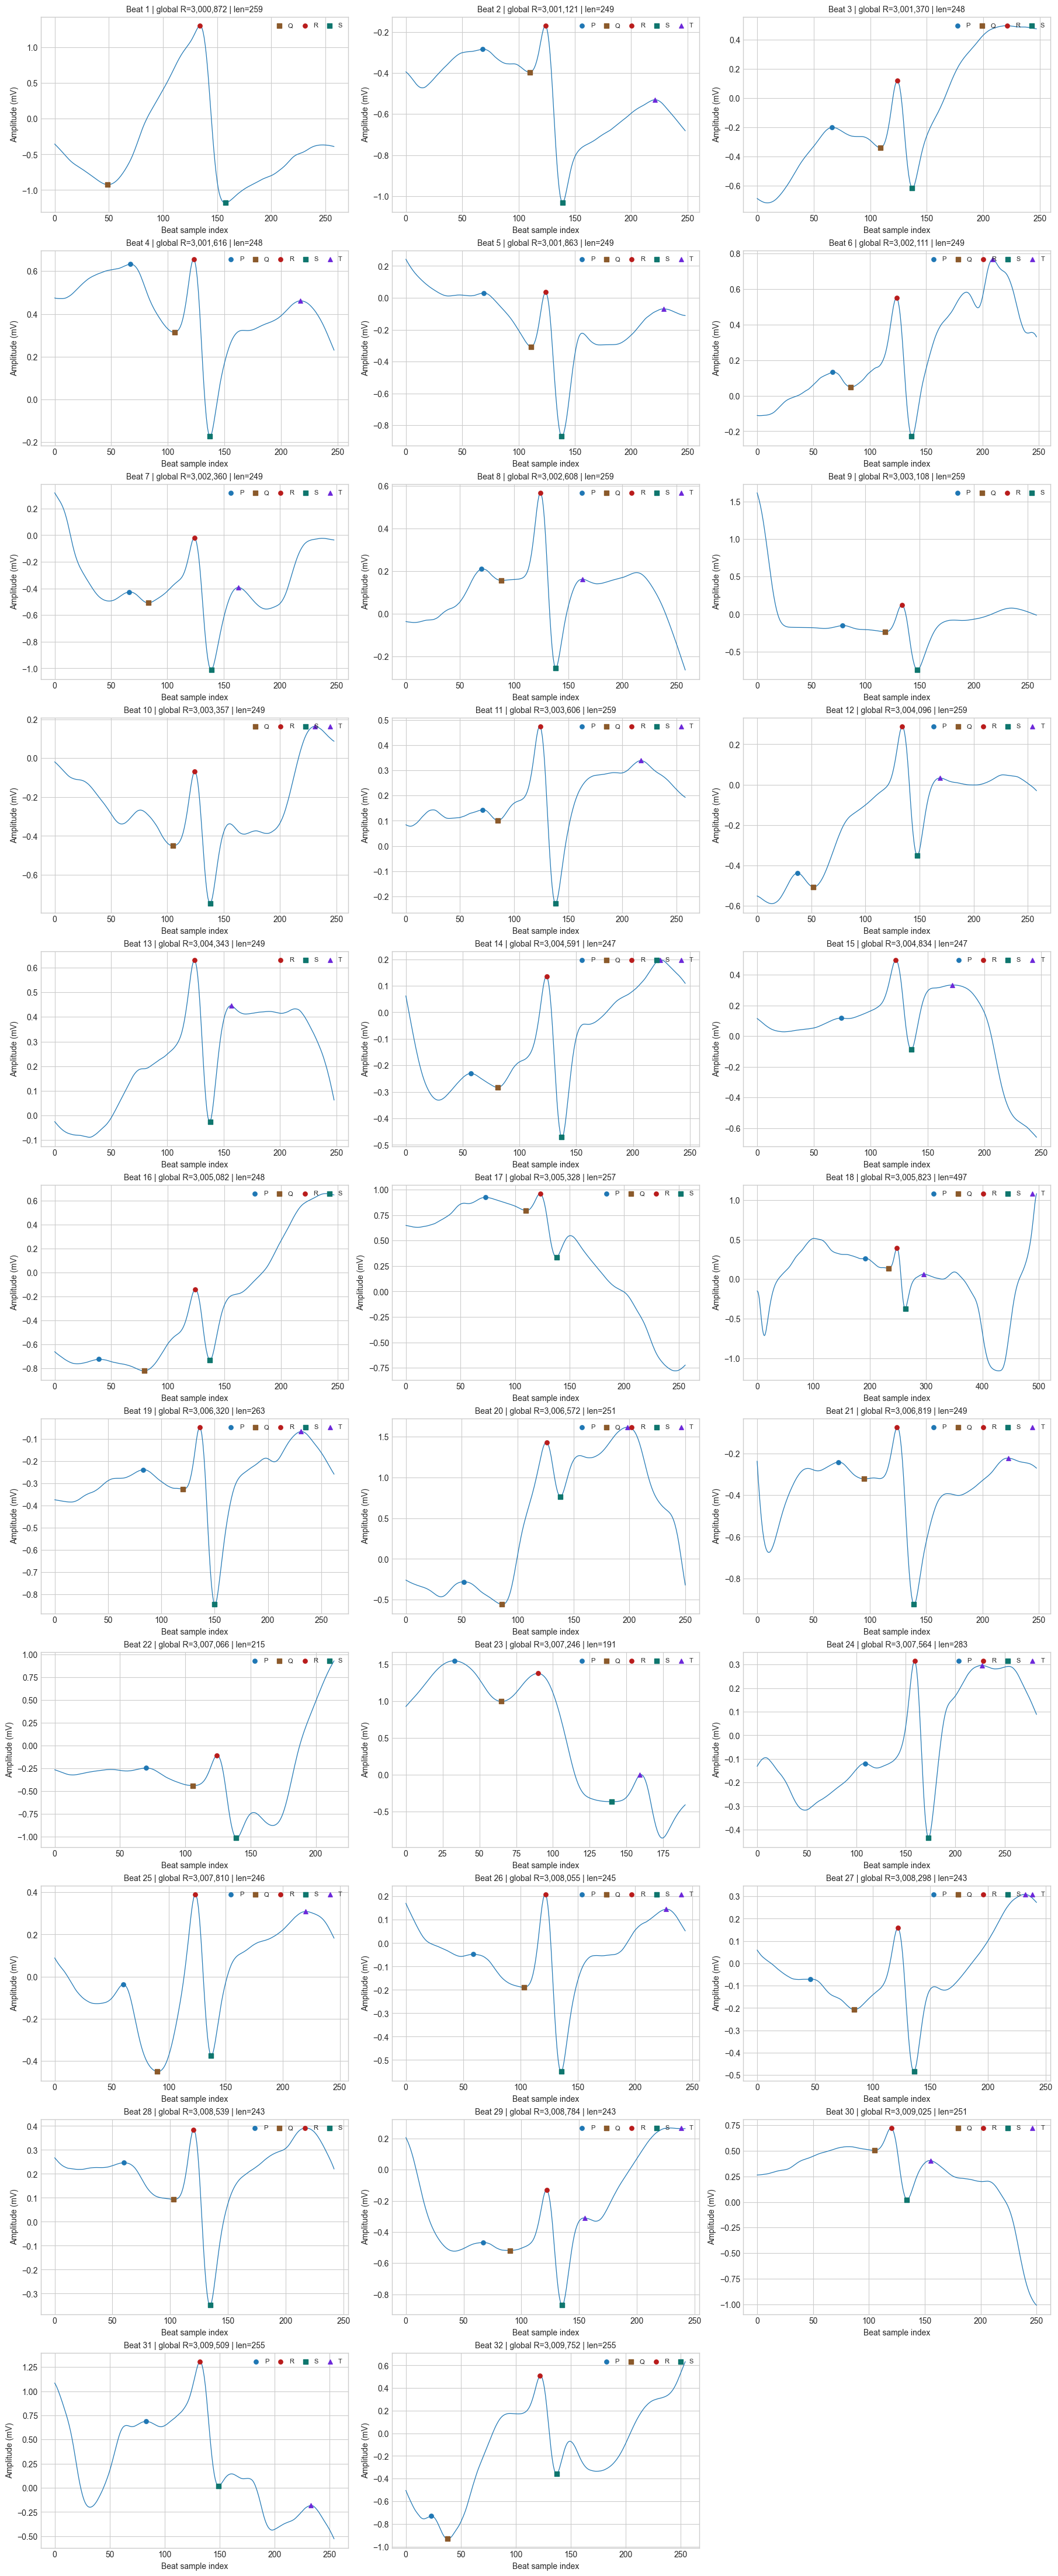

In [184]:
# Cell 9: Run delineation once on the continuous EARLY neurokit-cleaned CH2 signal,
# using only the accepted R-peaks from Cell 8. Then project the resulting PQRST markers
# back into each accepted beat window for visualization.

DELINEATION_SAMPLING_RATE = 500
DELINEATION_METHOD = "dwt"
PQRST_MARKER_STYLES = {
    "P": {"color": "#1f77b4", "marker": "o"},
    "Q": {"color": "#8b5a2b", "marker": "s"},
    "R": {"color": "#b91c1c", "marker": "o"},
    "S": {"color": "#0f766e", "marker": "s"},
    "T": {"color": "#6d28d9", "marker": "^"},
}


def extract_delineation_positions(delineate: dict, key: str, signal_length: int) -> np.ndarray:
    values = delineate.get(key, []) if isinstance(delineate, dict) else []
    if values is None:
        return np.array([], dtype=int)
    if hasattr(values, "tolist"):
        values = values.tolist()

    positions = []
    for value in values:
        if value is None:
            continue
        try:
            numeric_value = float(value)
        except (TypeError, ValueError):
            continue
        if np.isnan(numeric_value):
            continue
        index = int(round(numeric_value))
        if 0 <= index < signal_length:
            positions.append(index)
    return np.asarray(sorted(set(positions)), dtype=int)


accepted_r_peaks_for_delineation = np.asarray(
    [int(beat["r_peak_sample"]) for beat in accepted_heartbeat_segments_stage_2],
    dtype=int,
)

print(f"Accepted beats available for delineation plotting: {len(accepted_heartbeat_segments_stage_2):,}")
print(f"Accepted R-peaks used for continuous delineation: {len(accepted_r_peaks_for_delineation):,}")

if len(accepted_r_peaks_for_delineation) == 0:
    print("No accepted R-peaks available from Cell 8.")
else:
    delineate_result = nk.ecg_delineate(
        source_signal,
        accepted_r_peaks_for_delineation,
        sampling_rate=DELINEATION_SAMPLING_RATE,
        method=DELINEATION_METHOD,
    )
    if isinstance(delineate_result, tuple):
        _, delineate = delineate_result
    else:
        delineate = delineate_result

    global_marker_positions = {
        "P": extract_delineation_positions(delineate, "ECG_P_Peaks", len(source_signal)),
        "Q": extract_delineation_positions(delineate, "ECG_Q_Peaks", len(source_signal)),
        "R": accepted_r_peaks_for_delineation,
        "S": extract_delineation_positions(delineate, "ECG_S_Peaks", len(source_signal)),
        "T": extract_delineation_positions(delineate, "ECG_T_Peaks", len(source_signal)),
    }

    fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
    full_signal_x = early_start + np.arange(len(source_signal))
    ax.plot(full_signal_x, source_signal, color="#1f77b4", linewidth=0.9, label="CH2 neurokit")

    full_signal_marker_labels_drawn = set()
    for label, positions in global_marker_positions.items():
        if len(positions) == 0:
            continue
        style = PQRST_MARKER_STYLES[label]
        marker_label = label if label not in full_signal_marker_labels_drawn else None
        ax.scatter(
            early_start + positions,
            source_signal[positions],
            s=28,
            c=style["color"],
            marker=style["marker"],
            label=marker_label,
            zorder=3,
        )
        full_signal_marker_labels_drawn.add(label)

    ax.set_title("EARLY neurokit-cleaned CH2 with accepted R-peaks and continuous-signal PQRST delineation")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Amplitude (mV)")
    ax.legend(loc="upper right", ncol=6, fontsize=8, handletextpad=0.3, columnspacing=0.8)
    plt.show()

    beat_delineation_results = []
    for beat in accepted_heartbeat_segments_stage_2:
        start_local = int(beat["start_sample"] - early_start)
        end_local = int(beat["end_sample"] - early_start)
        beat_markers_local = {}
        for label, positions in global_marker_positions.items():
            beat_markers_local[label] = positions[(positions >= start_local) & (positions <= end_local)] - start_local
        beat_delineation_results.append(
            {
                **beat,
                "markers": beat_markers_local,
            }
        )

    ncols = 3
    nrows = int(np.ceil(len(beat_delineation_results) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, max(4 * nrows, 4)), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for axis, beat in zip(axes, beat_delineation_results):
        beat_signal = np.asarray(beat["signal"], dtype=float)
        beat_x = np.arange(len(beat_signal))
        axis.plot(beat_x, beat_signal, color="#1f77b4", linewidth=0.9)

        for label, positions in beat["markers"].items():
            if len(positions) == 0:
                continue
            style = PQRST_MARKER_STYLES[label]
            axis.scatter(
                positions,
                beat_signal[positions],
                s=28,
                c=style["color"],
                marker=style["marker"],
                label=label,
                zorder=3,
            )

        axis.set_title(
            f"Beat {beat['beat_index']} | global R={beat['r_peak_sample'] + early_start:,} | len={len(beat_signal)}",
            fontsize=10,
        )
        axis.set_xlabel("Beat sample index")
        axis.set_ylabel("Amplitude (mV)")
        axis.legend(loc="upper right", fontsize=8, ncol=5, handletextpad=0.3, columnspacing=0.8)

    for axis in axes[len(beat_delineation_results):]:
        axis.axis("off")

    plt.show()


Beats entering Cell 10 review: 32
Normal beats after Cell 10 review: 13
Suspicious beats after Cell 10 review: 5
Invalid beats after Cell 10 review: 14
Review reasons:
  missing_markers: P: 2
  missing_markers: P, Q: 1
  missing_markers: P, T: 1
  missing_markers: Q: 3
  missing_markers: T: 7
  p_above_r: 1
  t_above_r: 5
First 10 flagged beats:
  beat_index=  1 | global R=3,000,872 | reasons=missing_markers: P, T
  beat_index=  3 | global R=3,001,370 | reasons=missing_markers: T
  beat_index=  6 | global R=3,002,111 | reasons=t_above_r
  beat_index=  9 | global R=3,003,108 | reasons=missing_markers: T
  beat_index= 10 | global R=3,003,357 | reasons=missing_markers: P; t_above_r
  beat_index= 13 | global R=3,004,343 | reasons=missing_markers: P, Q
  beat_index= 14 | global R=3,004,591 | reasons=t_above_r
  beat_index= 15 | global R=3,004,834 | reasons=missing_markers: Q
  beat_index= 16 | global R=3,005,082 | reasons=missing_markers: T
  beat_index= 17 | global R=3,005,328 | reasons=mi

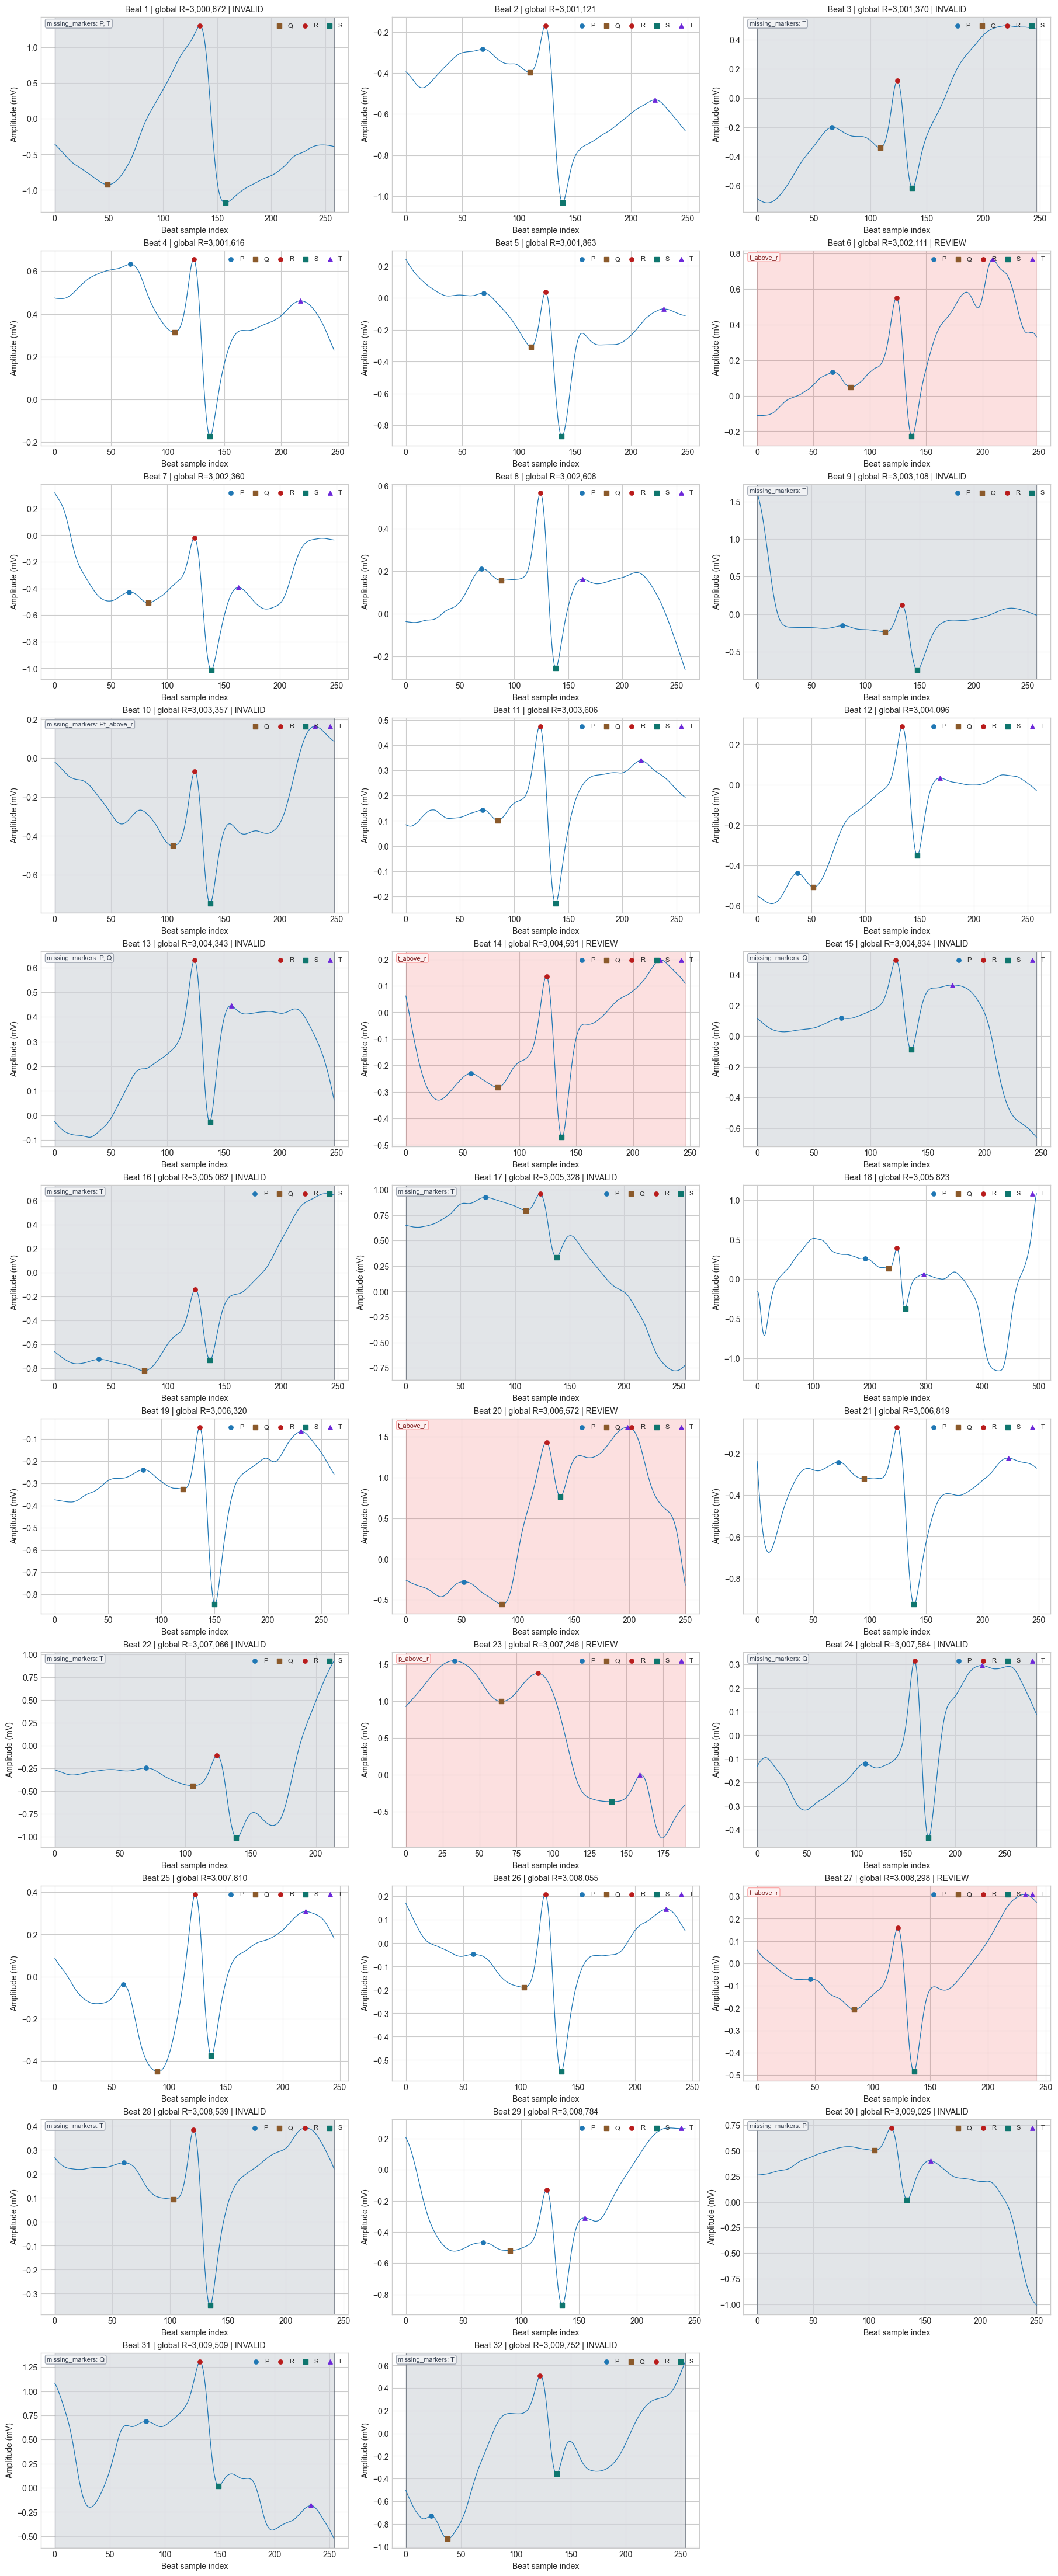

In [186]:
# Cell 10: Review delineated beats with two visual categories.
# INVALID (gray): missing markers or invalid P-Q-R-S-T ordering.
# SUSPICIOUS (red): P or T amplitude higher than R.

beats_after_pt_review = []
invalid_beats_pt_review = []
suspicious_beats_pt_review = []
normal_beats_pt_review = []

for beat in beat_delineation_results:
    beat_signal = np.asarray(beat["signal"], dtype=float)
    markers = beat["markers"]
    r_positions = np.asarray(markers.get("R", []), dtype=int)
    p_positions = np.asarray(markers.get("P", []), dtype=int)
    q_positions = np.asarray(markers.get("Q", []), dtype=int)
    s_positions = np.asarray(markers.get("S", []), dtype=int)
    t_positions = np.asarray(markers.get("T", []), dtype=int)

    invalid_reasons = []
    suspicious_reasons = []

    missing_markers = [
        label
        for label, positions in {
            "P": p_positions,
            "Q": q_positions,
            "R": r_positions,
            "S": s_positions,
            "T": t_positions,
        }.items()
        if len(positions) == 0
    ]
    if missing_markers:
        invalid_reasons.append("missing_markers: " + ", ".join(missing_markers))

    if not missing_markers:
        marker_sequence = [
            int(p_positions[0]),
            int(q_positions[0]),
            int(r_positions[0]),
            int(s_positions[0]),
            int(t_positions[0]),
        ]
        if marker_sequence != sorted(marker_sequence):
            invalid_reasons.append("invalid_marker_sequence")

    r_amplitude = float(np.max(beat_signal[r_positions])) if len(r_positions) else None
    if r_amplitude is not None:
        if len(p_positions) and np.any(beat_signal[p_positions] > r_amplitude):
            suspicious_reasons.append("p_above_r")
        if len(t_positions) and np.any(beat_signal[t_positions] > r_amplitude):
            suspicious_reasons.append("t_above_r")

    beat_result = {
        **beat,
        "invalid_reasons": invalid_reasons,
        "suspicious_reasons": suspicious_reasons,
        "review_reasons": [*invalid_reasons, *suspicious_reasons],
        "is_invalid": len(invalid_reasons) > 0,
        "is_suspicious": len(invalid_reasons) == 0 and len(suspicious_reasons) > 0,
        "r_amplitude": r_amplitude,
    }
    beats_after_pt_review.append(beat_result)
    if beat_result["is_invalid"]:
        invalid_beats_pt_review.append(beat_result)
    elif beat_result["is_suspicious"]:
        suspicious_beats_pt_review.append(beat_result)
    else:
        normal_beats_pt_review.append(beat_result)

print(f"Beats entering Cell 10 review: {len(beat_delineation_results):,}")
print(f"Normal beats after Cell 10 review: {len(normal_beats_pt_review):,}")
print(f"Suspicious beats after Cell 10 review: {len(suspicious_beats_pt_review):,}")
print(f"Invalid beats after Cell 10 review: {len(invalid_beats_pt_review):,}")

reason_counts = {}
for beat in beats_after_pt_review:
    for reason in beat["review_reasons"]:
        reason_counts[reason] = reason_counts.get(reason, 0) + 1

if reason_counts:
    print("Review reasons:")
    for reason, count in sorted(reason_counts.items()):
        print(f"  {reason}: {count}")

flagged_beats = [beat for beat in beats_after_pt_review if beat["review_reasons"]]
if flagged_beats:
    print("First 10 flagged beats:")
    for beat in flagged_beats[:10]:
        print(
            f"  beat_index={beat['beat_index']:>3} | global R={beat['r_peak_sample'] + early_start:,} | reasons={'; '.join(beat['review_reasons'])}"
        )

if not beats_after_pt_review:
    print("No beats available for Cell 10 review visualization.")
else:
    ncols = 3
    nrows = int(np.ceil(len(beats_after_pt_review) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, max(4 * nrows, 4)), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for axis, beat in zip(axes, beats_after_pt_review):
        beat_signal = np.asarray(beat["signal"], dtype=float)
        beat_x = np.arange(len(beat_signal))

        if beat["is_invalid"]:
            axis.axvspan(
                0,
                len(beat_signal) - 1,
                facecolor="#d1d5db",
                edgecolor="#4b5563",
                linewidth=0.9,
                alpha=0.62,
            )
        elif beat["is_suspicious"]:
            axis.axvspan(
                0,
                len(beat_signal) - 1,
                facecolor="#ef4444",
                edgecolor="#991b1b",
                linewidth=0.9,
                alpha=0.16,
            )

        axis.plot(beat_x, beat_signal, color="#1f77b4", linewidth=0.9)

        for label, positions in beat["markers"].items():
            positions = np.asarray(positions, dtype=int)
            if len(positions) == 0:
                continue
            style = PQRST_MARKER_STYLES[label]
            axis.scatter(
                positions,
                beat_signal[positions],
                s=28,
                c=style["color"],
                marker=style["marker"],
                label=label,
                zorder=3,
            )

        title = f"Beat {beat['beat_index']} | global R={beat['r_peak_sample'] + early_start:,}"
        if beat["is_invalid"]:
            title += " | INVALID"
        elif beat["is_suspicious"]:
            title += " | REVIEW"
        axis.set_title(title, fontsize=10)
        axis.set_xlabel("Beat sample index")
        axis.set_ylabel("Amplitude (mV)")
        if beat["review_reasons"]:
            note_face = "#f3f4f6" if beat["is_invalid"] else "#fef2f2"
            note_edge = "#9ca3af" if beat["is_invalid"] else "#fca5a5"
            note_text = "#374151" if beat["is_invalid"] else "#7f1d1d"
            axis.text(
                0.02,
                0.98,
                "".join(beat["review_reasons"]),
                transform=axis.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                color=note_text,
                bbox={"boxstyle": "round,pad=0.25", "facecolor": note_face, "edgecolor": note_edge, "alpha": 0.92},
            )
        axis.legend(loc="upper right", fontsize=8, ncol=5, handletextpad=0.3, columnspacing=0.8)

    for axis in axes[len(beats_after_pt_review):]:
        axis.axis("off")

    plt.show()
